In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from src.feature_engineering import build_feature_dataset
from src.train_model import (load_features_config, load_model_params, get_X_y, train_classification_models, add_predictions_to_df)
from src.signal_generator import generate_signals_from_prob
from src.backtest import backtest_signals, summarize_performance

In [2]:
df = build_feature_dataset(market_path='data/market_data_ml.csv', tickers_path='data/tickers-1.csv', task='classification', horizon=1)
df.head()

,date,ticker,open,high,low,close,volume,sma_5,sma_10,sma_20,return,log_return,return_1d,return_3d,return_5d,rsi_14,macd,macd_signal,macd_hist,direction
0,2023-01-27,AAPL,296.57,298.05,296.35,297.33,3208067,295.482,295.273,296.963,0.003138,0.003133,0.007170,-0.007741,0.009815,52.058219,-0.745168,-0.744918,-0.000250,0
1,2023-01-30,AAPL,297.00,298.80,296.96,297.26,1534651,295.766,295.323,296.910,-0.000235,-0.000235,0.003138,0.002521,-0.001552,51.755515,-0.593732,-0.714681,0.120949,0
2,2023-01-31,AAPL,295.96,296.66,295.49,296.27,3188931,296.310,295.468,296.750,-0.003330,-0.003336,-0.000235,0.007170,-0.007741,47.544818,-0.547294,-0.681203,0.133910,0
3,2023-02-01,AAPL,294.65,296.04,294.63,295.97,2689693,296.646,295.663,296.641,-0.001013,-0.001013,-0.003330,0.003138,0.002521,46.315142,-0.528605,-0.650684,0.122079,1
4,2023-02-02,AAPL,298.58,298.72,298.38,298.50,3611381,297.066,296.171,296.609,0.008548,0.008512,-0.001013,-0.000235,0.007170,56.526745,-0.306116,-0.581770,0.275654,0


In [3]:
features_cfg = load_features_config('data/features_config.json')
model_params = load_model_params('data/model_params.json')
X, y = get_X_y(df, features_cfg)
X.shape, y.shape

((1205, 7), (1205,))

In [4]:
models, metrics = train_classification_models(X, y, model_params)
metrics

{'log_reg': {'cv_accuracy': 0.5383149827288428,
  'test_accuracy': 0.42323651452282157,
  'precision': 0.5,
  'recall': 0.11510791366906475,
  'confusion_matrix': [[86, 16], [123, 16]]},
 'rf_clf': {'cv_accuracy': 0.5206876079447322,
  'test_accuracy': 0.43983402489626555,
  'precision': 0.5714285714285714,
  'recall': 0.11510791366906475,
  'confusion_matrix': [[90, 12], [123, 16]],
  'feature_importances': [0.18941345096225465,
   0.12197455672068566,
   0.1391022317143786,
   0.1453232745775861,
   0.11942826250361208,
   0.13726525198744816,
   0.1474929715340348]}}

In [14]:
df_pred = add_predictions_to_df(df, models, features_cfg)
df_pred = generate_signals_from_prob(df_pred, 'proba_log_reg', threshold=0.5)
df_pred[['date', 'ticker', 'close', 'proba_log_reg', 'signal']].head()

,date,ticker,close,proba_log_reg,signal
0,2023-01-27,AAPL,297.33,0.444068,0
1,2023-01-30,AAPL,297.26,0.459220,0
2,2023-01-31,AAPL,296.27,0.463409,0
3,2023-02-01,AAPL,295.97,0.424674,0
4,2023-02-02,AAPL,298.50,0.412698,0


In [15]:
df_lr = df_pred.copy()
equity_lr = backtest_signals(df_lr)
perf_lr = summarize_performance(equity_lr)
perf_lr

{'strategy_cum': 0.013667296388903294,
 'benchmark_cum': -0.01772753217001588,
 'strategy_ann': 0.014295553175075026,
 'benchmark_ann': -0.018529130593761045,
 'strategy_vol': 0.03152652945638538,
 'benchmark_vol': 0.06379105350894766,
 'strategy_sharpe': 0.4534451911318646}

In [16]:
df_rf = df_pred.copy()
df_rf = generate_signals_from_prob(df_rf, 'proba_rf_clf', threshold=0.5)
equity_rf = backtest_signals(df_rf)
perf_rf = summarize_performance(equity_rf)
perf_rf

{'strategy_cum': 0.4100528465855513,
 'benchmark_cum': -0.01772753217001588,
 'strategy_ann': 0.4323427806126787,
 'benchmark_ann': -0.018529130593761045,
 'strategy_vol': 0.03395802708623706,
 'benchmark_vol': 0.06379105350894766,
 'strategy_sharpe': 12.731681364018467}

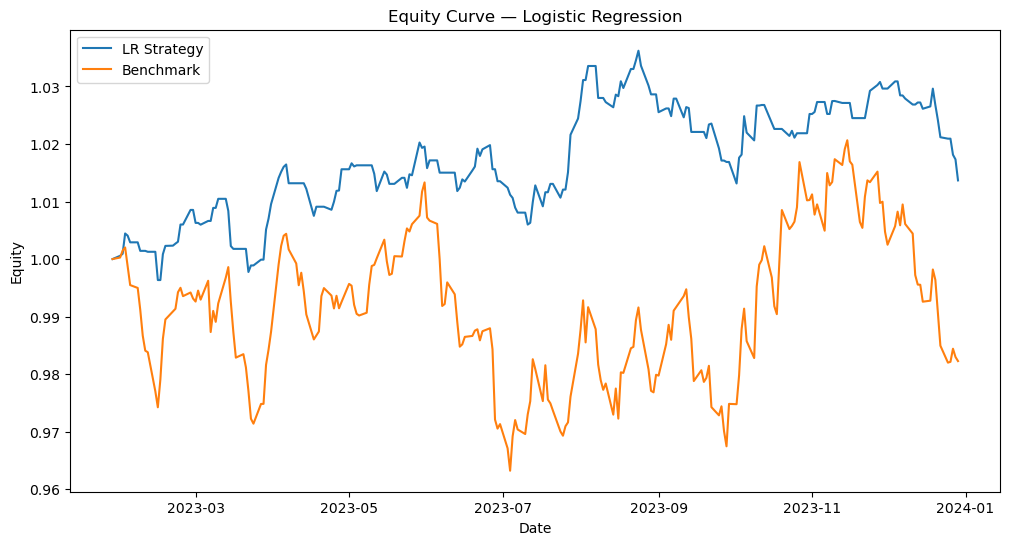

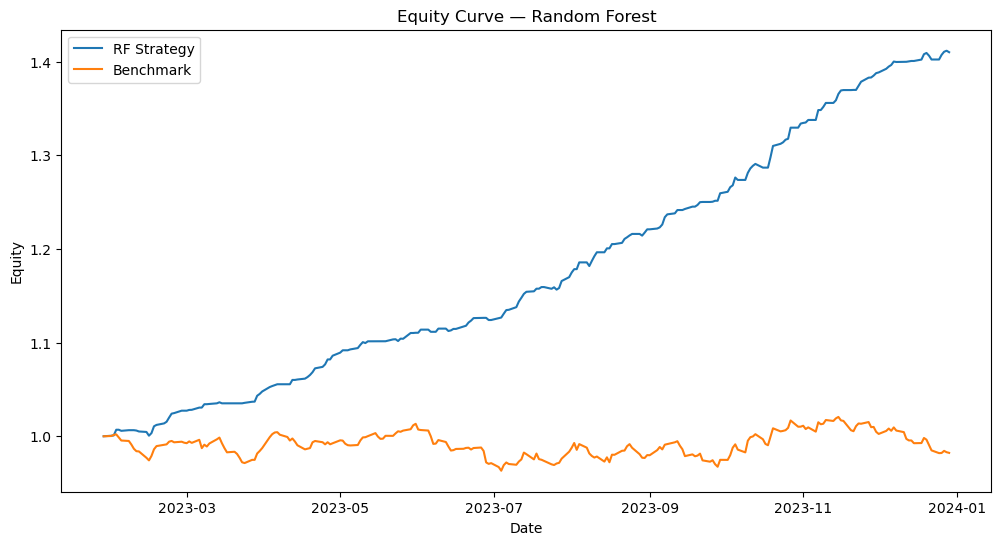

In [19]:
plt.figure(figsize=(12,6))
plt.plot(equity_lr.index, equity_lr['strategy_equity'], label='LR Strategy')
plt.plot(equity_lr.index, equity_lr['benchmark_equity'], label='Benchmark')
plt.legend()
plt.title('Equity Curve — Logistic Regression')
plt.xlabel('Date')
plt.ylabel('Equity')
plt.show()

plt.figure(figsize=(12,6))
plt.plot(equity_rf.index, equity_rf['strategy_equity'], label='RF Strategy')
plt.plot(equity_rf.index, equity_rf['benchmark_equity'], label='Benchmark')
plt.legend()
plt.title('Equity Curve — Random Forest')
plt.xlabel('Date')
plt.ylabel('Equity')
plt.show()

In [20]:
plt.savefig('lr_equity.png', dpi=300, bbox_inches='tight')
plt.savefig('rf_equity.png', dpi=300, bbox_inches='tight')

<Figure size 640x480 with 0 Axes>